# Notebook 2 — Visão Computacional: Objetos, Características e Classificação

## Objetivo deste notebook

Aplicar visão computacional em tarefas mais próximas de IA:

1. criar uma cena artificial;
2. segmentar objetos;
3. detectar contornos;
4. extrair características;
5. classificar imagens de dígitos;
6. entender a ideia de convolução e CNN.

## Bloco 0 — Preparação do ambiente

Importar bibliotecas principais.

In [1]:
import sys
import subprocess
import importlib.util

def instalar_se_precisar(pacote, nome_import=None):
    nome_import = nome_import or pacote
    if importlib.util.find_spec(nome_import) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])

instalar_se_precisar("opencv-python", "cv2")
instalar_se_precisar("scikit-learn", "sklearn")

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

print("Ambiente pronto!")

Ambiente pronto!


## Bloco 1 — Criando uma imagem/cena artificial

Vamos criar uma imagem com objetos simples.

Isso facilita entender como o computador detecta regiões.

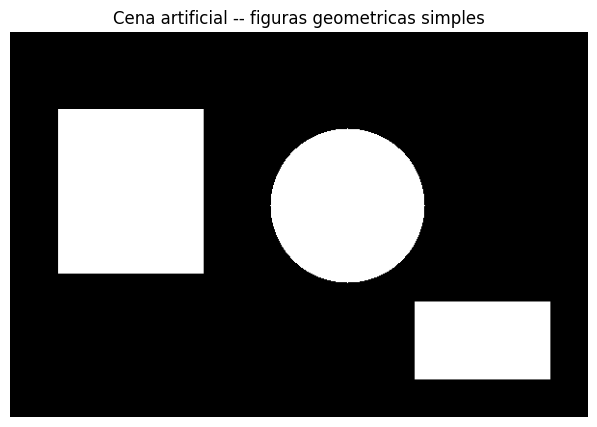

In [3]:
cena = np.zeros((400, 600), dtype=np.uint8)

cv2.rectangle(cena, (50, 80), (200, 250), 255, -1)
cv2.circle(cena, (350, 180), 80, 255, -1)
cv2.rectangle(cena, (420, 280), (560, 360), 255, -1)

plt.imshow(cena, cmap="gray")
plt.title("Cena artificial -- figuras geometricas simples")
plt.axis("off")
plt.show()

## Bloco 2 — Detectando contornos

Contornos são fronteiras de regiões conectadas.

Fronteiras = derivadas intensas ou alteracoes bruscas.

Com eles, conseguimos identificar objetos.

Objeto 1: x=420, y=280, largura=141, altura=81, área=11200
Objeto 2: x=270, y=100, largura=161, altura=161, área=19854
Objeto 3: x=50, y=80, largura=151, altura=171, área=25500


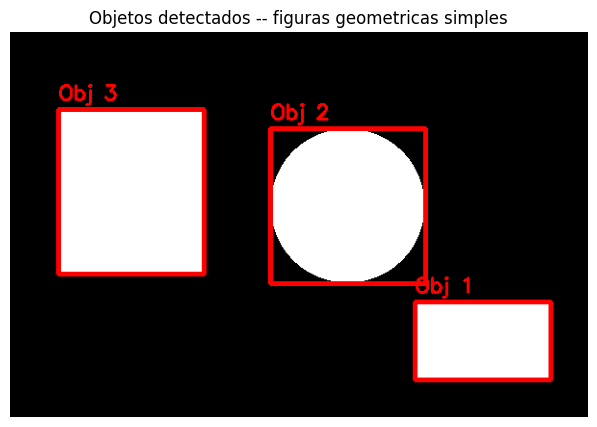

In [5]:
contornos, _ = cv2.findContours(cena, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

resultado = cv2.cvtColor(cena, cv2.COLOR_GRAY2RGB)

for i, contorno in enumerate(contornos, start=1):
    x, y, w, h = cv2.boundingRect(contorno)
    area = cv2.contourArea(contorno)

    cv2.rectangle(resultado, (x, y), (x+w, y+h), (255, 0, 0), 3)
    cv2.putText(resultado, f"Obj {i}", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    print(f"Objeto {i}: x={x}, y={y}, largura={w}, altura={h}, área={area:.0f}")

plt.imshow(resultado)
plt.title("Objetos detectados -- figuras geometricas simples")
plt.axis("off")
plt.show()

## Bloco 3 — Extraindo características

Imagens geometricas em forma de vetores/matrizes.

Exemplos de características:

- área;
- perímetro;
- largura;
- altura;
- razão largura/altura.

Essa ponte imagem → tabela é muito importante em IA clássica.

In [8]:
caracteristicas = []

for i, contorno in enumerate(contornos, start=1):
    x, y, w, h = cv2.boundingRect(contorno)
    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True)

    caracteristicas.append({
        "objeto": i,
        "largura": w,
        "altura": h,
        "area": area,
        "perimetro": round(perimetro,2),
        "razao_largura_altura": round(w / h, 2), # largura / altura
        "razao_altura_largura": round(h / w, 2)  # altura
    })

for item in caracteristicas:
    print(item)

{'objeto': 1, 'largura': 141, 'altura': 81, 'area': 11200.0, 'perimetro': 440.0, 'razao_largura_altura': 1.74, 'razao_altura_largura': 0.57}
{'objeto': 2, 'largura': 161, 'altura': 161, 'area': 19854.0, 'perimetro': 529.87, 'razao_largura_altura': 1.0, 'razao_altura_largura': 1.0}
{'objeto': 3, 'largura': 151, 'altura': 171, 'area': 25500.0, 'perimetro': 640.0, 'razao_largura_altura': 0.88, 'razao_altura_largura': 1.13}


## Bloco 4 — Classificação de imagens: dataset de dígitos

Vamos usar um dataset pequeno, com imagens 8x8 de números escritos à mão.

O objetivo é prever o dígito: 0, 1, 2, ..., 9.

Usar metodos matematicos vetoriais para identificar algo escrito.

Formato das imagens: (1797, 8, 8)
Formato dos rótulos: (1797,)


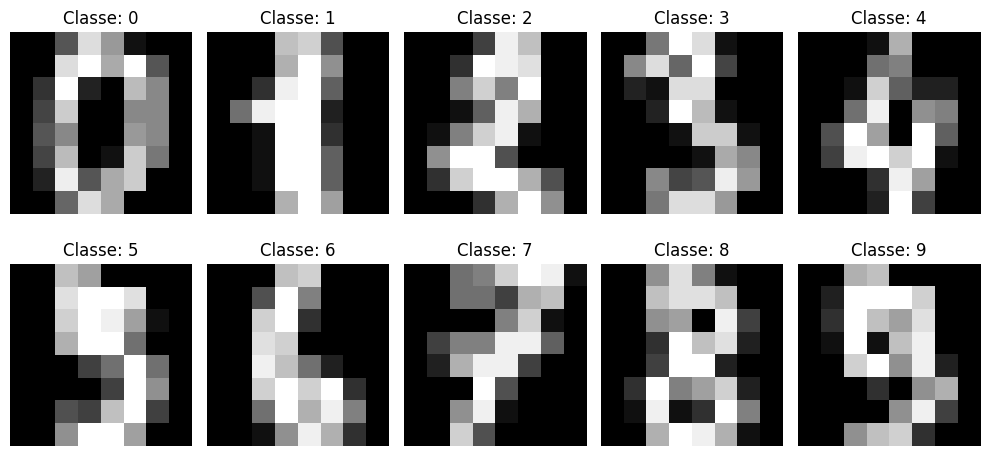

In [9]:
digits = load_digits()

X = digits.images
y = digits.target

print("Formato das imagens:", X.shape)
print("Formato dos rótulos:", y.shape)

fig, axs = plt.subplots(2, 5, figsize=(10, 5))

for ax, img, label in zip(axs.ravel(), X[:10], y[:10]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Classe: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Bloco 5 — Preparando os dados

Modelos tradicionais recebem uma tabela.

Por isso, cada imagem 8x8 será transformada em um vetor com 64 posições.

In [10]:
X_flat = X.reshape((len(X), -1))

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Antes do tratamento:", X.shape)
print("Depois da modificacao flatten:", X_flat.shape)
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Antes do tratamento: (1797, 8, 8)
Depois da modificacao flatten: (1797, 64)
Treino: (1347, 64)
Teste: (450, 64)


## Bloco 6 — Treinando uma rede neural simples

Usaremos uma MLP: multi_layer perceptron.

Uma das primeiras redes neurais projetadas. Operacao simples.

Ela não é CNN, mas serve para mostrar a lógica de classificação de imagens com rede neural.

In [15]:
modelo = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

modelo.fit(X_train, y_train)

print(f"Acurácia no treino: {modelo.score(X_train, y_train):.4f}")
print(f"Acurácia no teste:  {modelo.score(X_test, y_test):.4f}")
print("A diferenca entre acuracias mostra se o modelo consegue abstrair")

Acurácia no treino: 1.0000
Acurácia no teste:  0.9711
A diferenca entre acuracias mostra se o modelo consegue abstrair


## Bloco 7 — Avaliando o modelo

A matriz de confusão mostra onde o modelo acerta e onde se confunde.

Falso positivo = dizemos que algo é, mas na verdade nao o é.

Falso negativo = dizemos que algo nao é, mas na verdade é.

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.92      0.98      0.95        46
           2       0.98      1.00      0.99        44
           3       1.00      0.98      0.99        46
           4       0.98      0.98      0.98        45
           5       0.98      0.98      0.98        46
           6       0.98      0.98      0.98        45
           7       0.98      1.00      0.99        45
           8       1.00      0.88      0.94        43
           9       0.94      0.98      0.96        45

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



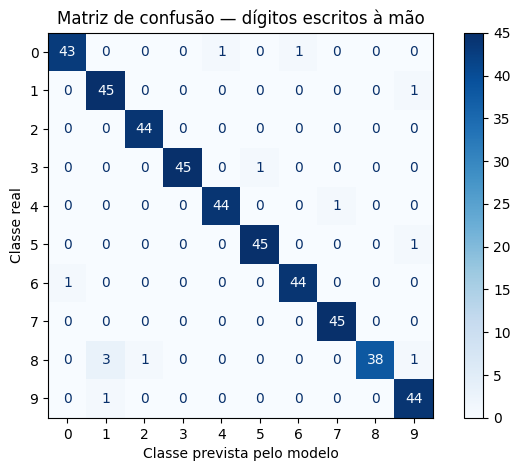

In [20]:
# O modelo faz previsões usando os dados de teste
y_pred = modelo.predict(X_test)

# Relatório com métricas principais:
# precision: entre os casos previstos como uma classe, quantos estavam corretos
# recall: entre os casos reais de uma classe, quantos o modelo encontrou
# f1-score: equilíbrio entre precision e recall
# support: quantidade real de exemplos daquela classe no teste
print("Relatório de classificação:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de confusão — dígitos escritos à mão")

# Explicação visual:
# - Linhas: classe real
# - Colunas: classe prevista pelo modelo
# - Diagonal principal: acertos
# - Fora da diagonal: erros
# - Escala de cores à direita: quanto mais escuro o azul, maior a quantidade de casos
plt.xlabel("Classe prevista pelo modelo")
plt.ylabel("Classe real")

plt.show()

In [21]:
# Bloco 8 — Interpretando os números da matriz de confusão

from sklearn.metrics import confusion_matrix
import numpy as np

# Calcula novamente a matriz de confusão em forma de matriz numérica
cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusão em formato numérico:")
print(cm)

print("\n--- Interpretação da diagonal principal: acertos ---")

# A diagonal principal representa os acertos:
# classe real = classe prevista
for classe in range(cm.shape[0]):
    acertos = cm[classe, classe]
    total_real = cm[classe, :].sum()
    erros = total_real - acertos

    print(
        f"Classe {classe}: "
        f"{acertos} acertos em {total_real} exemplos reais. "
        f"Erros nessa classe: {erros}."
    )

print("\n--- Interpretação dos valores fora da diagonal: erros ---")

# Os valores fora da diagonal representam confusões do modelo:
# linha = classe real
# coluna = classe prevista
houve_erro = False

for classe_real in range(cm.shape[0]):
    for classe_prevista in range(cm.shape[1]):

        # Ignora a diagonal principal, pois ela representa acertos
        if classe_real != classe_prevista:
            quantidade = cm[classe_real, classe_prevista]

            # Mostra apenas os erros, isto é, valores diferentes de zero
            if quantidade > 0:
                houve_erro = True
                print(
                    f"O modelo confundiu {quantidade} imagem(ns) da classe real "
                    f"{classe_real} como se fossem da classe {classe_prevista}."
                )

if not houve_erro:
    print("Não houve erros fora da diagonal principal.")

Matriz de confusão em formato numérico:
[[43  0  0  0  1  0  1  0  0  0]
 [ 0 45  0  0  0  0  0  0  0  1]
 [ 0  0 44  0  0  0  0  0  0  0]
 [ 0  0  0 45  0  1  0  0  0  0]
 [ 0  0  0  0 44  0  0  1  0  0]
 [ 0  0  0  0  0 45  0  0  0  1]
 [ 1  0  0  0  0  0 44  0  0  0]
 [ 0  0  0  0  0  0  0 45  0  0]
 [ 0  3  1  0  0  0  0  0 38  1]
 [ 0  1  0  0  0  0  0  0  0 44]]

--- Interpretação da diagonal principal: acertos ---
Classe 0: 43 acertos em 45 exemplos reais. Erros nessa classe: 2.
Classe 1: 45 acertos em 46 exemplos reais. Erros nessa classe: 1.
Classe 2: 44 acertos em 44 exemplos reais. Erros nessa classe: 0.
Classe 3: 45 acertos em 46 exemplos reais. Erros nessa classe: 1.
Classe 4: 44 acertos em 45 exemplos reais. Erros nessa classe: 1.
Classe 5: 45 acertos em 46 exemplos reais. Erros nessa classe: 1.
Classe 6: 44 acertos em 45 exemplos reais. Erros nessa classe: 1.
Classe 7: 45 acertos em 45 exemplos reais. Erros nessa classe: 0.
Classe 8: 38 acertos em 43 exemplos reais. Erro

### Como ler os números da matriz de confusão

Na matriz de confusão, cada número indica uma quantidade de imagens.

A leitura correta é:

- **linha**: classe real da imagem;
- **coluna**: classe prevista pelo modelo;
- **diagonal principal**: acertos;
- **fora da diagonal principal**: erros.

Por exemplo, se aparece um valor `3` na linha `8` e na coluna `1`, isso significa:

> três imagens que eram realmente da classe `8` foram classificadas pelo modelo como `1`.

Portanto, os números fora da diagonal são importantes porque mostram exatamente **onde o modelo está se confundindo**.

No caso desta matriz, a maior parte dos valores altos está na diagonal principal, o que indica bom desempenho geral.  
Mesmo assim, existem alguns erros fora da diagonal, como confusões entre dígitos visualmente parecidos. Isso é esperado em problemas de reconhecimento de escrita manual, pois alguns números podem ter formatos semelhantes dependendo da escrita.

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        45
           1       0.92      0.98      0.95        46
           2       0.98      1.00      0.99        44
           3       1.00      0.98      0.99        46
           4       0.98      0.98      0.98        45
           5       0.98      0.98      0.98        46
           6       0.98      0.98      0.98        45
           7       0.98      1.00      0.99        45
           8       1.00      0.88      0.94        43
           9       0.94      0.98      0.96        45

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450



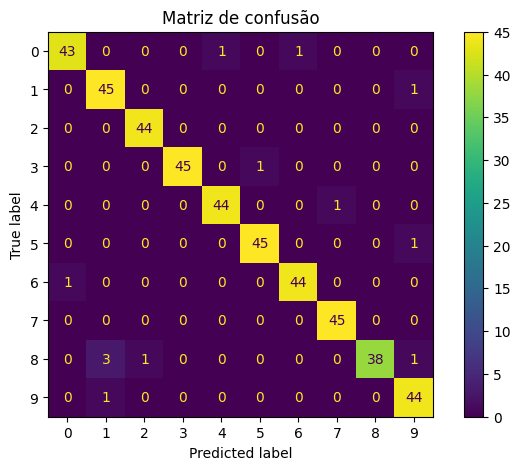

In [22]:
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusão")
plt.show()

## Bloco 8 — Visualizando previsões

Aqui olhamos exemplos reais do teste.

Isso ajuda a discutir erros e acertos.

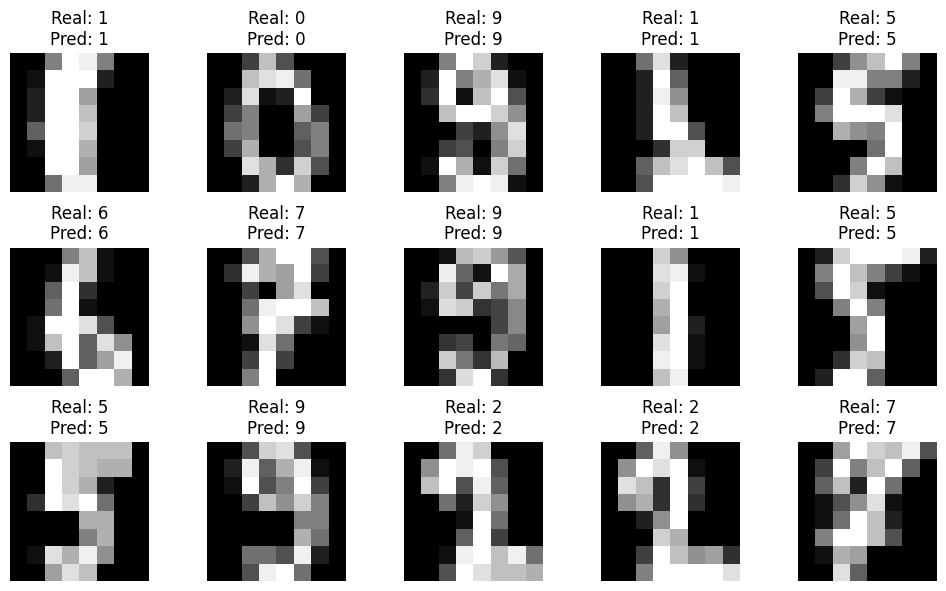

In [17]:
X_test_img = X_test.reshape((-1, 8, 8))

fig, axs = plt.subplots(3, 5, figsize=(10, 6))

for ax, img, real, pred in zip(axs.ravel(), X_test_img[:15], y_test[:15], y_pred[:15]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Real: {real}\nPred: {pred}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Bloco 9 — Ideia de convolução

Convolução é aplicar um filtro pequeno sobre a imagem.

CNN = Convulotional Neural Network. Rede neural avançada.

CNNs aprendem vários filtros automaticamente.

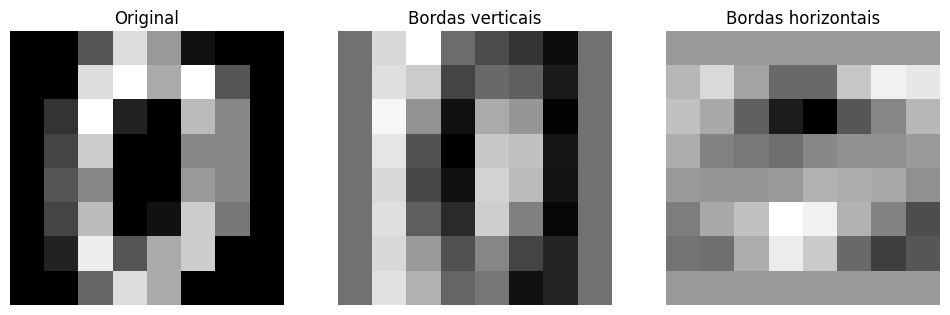

In [18]:
img = X[0].astype(np.float32)

kernel_vertical = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

kernel_horizontal = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=np.float32)

conv_vertical = cv2.filter2D(img, -1, kernel_vertical)
conv_horizontal = cv2.filter2D(img, -1, kernel_horizontal)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(img, cmap="gray")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(conv_vertical, cmap="gray")
axs[1].set_title("Bordas verticais")
axs[1].axis("off")

axs[2].imshow(conv_horizontal, cmap="gray")
axs[2].set_title("Bordas horizontais")
axs[2].axis("off")

plt.show()

## Bloco 10 — Pipeline de visão computacional

A lógica geral de um projeto costuma ser:

1. entrada da imagem;
2. pré-processamento;
3. segmentação ou detecção;
4. extração de características;
5. modelo de IA;
6. decisão final.

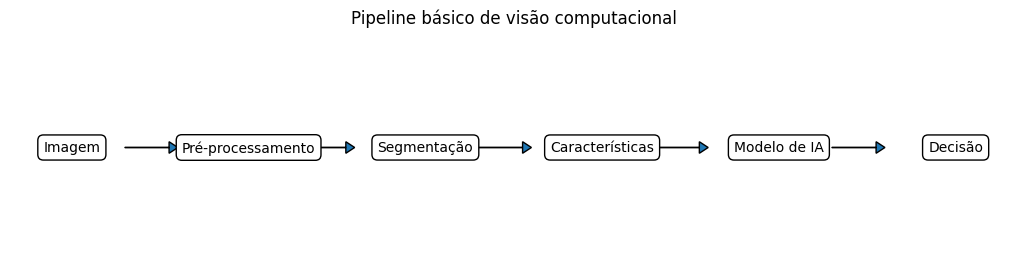

In [19]:
etapas = [
    "Imagem",
    "Pré-processamento",
    "Segmentação",
    "Características",
    "Modelo de IA",
    "Decisão"
]

plt.figure(figsize=(13, 3))

for i, etapa in enumerate(etapas):
    x = i * 2
    plt.text(x, 0.5, etapa, ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black"))
    if i < len(etapas) - 1:
        plt.arrow(x + 0.6, 0.5, 0.6, 0,
                  head_width=0.05, head_length=0.1,
                  length_includes_head=True)

plt.xlim(-0.7, 10.7)
plt.ylim(0, 1)
plt.axis("off")
plt.title("Pipeline básico de visão computacional")
plt.show()

## Fechamento do Notebook 2

Neste notebook, vimos:

1. detecção de objetos simples;
2. contornos;
3. extração de características;
4. classificação de dígitos;
5. avaliação com matriz de confusão;
6. ideia de convolução;
7. ponte para CNN.